# Import

In [1]:
import zarr
import shutil
import os
import sys
import calendar
import logging
import concurrent.futures
import geopandas as gpd
import xarray as xr
import zarr
from numcodecs import Blosc

#from retry import retry
#from mypythonlib import myfunctions, phenolopy
import os
import xarray as xr
from tqdm import tqdm
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import seaborn as sns
import numpy as np
from matplotlib.gridspec import GridSpec
from matplotlib import gridspec
from matplotlib.ticker import MaxNLocator, FuncFormatter
from matplotlib import cm
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import xarray as xr
from shapely.geometry import mapping, shape, MultiPolygon, box, Point
from affine import Affine
import rasterio
from shapely import wkt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import os
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
import matplotlib.patches as mpatches  # Import for custom legend
from dotenv import load_dotenv
import os
from pathlib import Path
import json
from tqdm import tqdm  # Import tqdm for the progress bar
import numpy as np

import rioxarray
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
import pandas as pd


# Set font sizes for various components
plt.rcParams.update({
    'font.size': 14,           # Global font size
    'axes.titlesize': 18,      # Title font size
    'axes.labelsize': 16,      # X and Y label font size
    'xtick.labelsize': 14,     # X tick label font size
    'ytick.labelsize': 14,     # Y tick label font size
})

In [2]:
import os, sys
import xarray as xr
import numpy as np
import glob
import pandas as pd
from datetime import datetime
from scipy.stats import zscore
from scipy.signal import savgol_filter, find_peaks
from scipy.ndimage import gaussian_filter

import glob
import xarray as xr
from shapely import wkt
import glob
import sys
sys.path.insert(1, '../Tools/')
import numpy as np
import xarray as xr
import geopandas as gpd


import geopandas as gpd
import pandas as pd

def remove_outliers(ds, method='median', user_factor=2, z_pval=0.05):
    """
    Takes an xarray dataset containing vegetation index variable and removes outliers within 
    the timeseries on a per-pixel basis. The resulting dataset contains the timeseries 
    with outliers set to nan. Can work on datasets with or without existing nan values.
    
    Parameters
    ----------
    ds: xarray Dataset
        A two-dimensional or multi-dimensional array 
    method: str
        The outlier detection method to apply to the dataset. The median method detects 
        outliers by calculating if values in pixel timeseries deviate more than a maximum 
        deviation (cutoff) from the median in a moving window (half window width = number 
        of values per year / 7) and it is lower than the mean value of its immediate neighbors 
        minus the cutoff or it is larger than the highest value of its immediate neighbor plus 
        The cutoff is the standard deviation of the entire time-series times a factor given by 
        the user. The second method, zscore, is similar but uses zscore to detect whether outlier
        is signficicantly (i.e. p-value) outside the population.
    user_factor: float
        An value between 0 to 10 which is used to 'multiply' the threshold cutoff. A higher factor 
        value results in few outliers (i.e. only the biggest outliers). Default factor is 2.
    z_pval: float
        The p-value for zscore method. A more significant p-value (i.e. 0.01) results in fewer
        outliers, a less significant p-value (i.e 0.1) results in more. Default is 0.05.
    Returns
    -------
    ds : xarray Dataset
        The original xarray Dataset inputted into the function, with a all detected outliers in the
        all the variables set to nan.
    """
    
    # notify user
    print('Outlier removal method: {0} with a user factor of: {1}'.format(method, user_factor))
    
    # check if type is xr dataset
    if type(ds) != xr.Dataset:
        raise TypeError('Not a dataset. Please provide a xarray dataset.')
        
    # check if time dimension is in dataset
    if 'time' not in list(ds.dims):
        raise ValueError('Time dimension not in dataset. Please ensure dataset has a time dimension.')
    
    # # check if dataset contains veg_index variable
    # if 'veg_index' not in list(ds.data_vars):
    #     raise ValueError('Vegetation index (veg_index) not in dataset. Please generate veg_index first.')
                        
    # check if dataset is 2D or above
    #if len(ds[' B01'].shape) == 1:
    #    raise Exception('Remove outliers does not operate on 1D datasets. Ensure it has an x, y and time dimension.')
        
    # check if user factor provided
    if user_factor <= 0:
        raise TypeError('User factor is less than 0. Please provide a value of 0 or above.')
        
    # check if pval provided if method is zscore
    if method == 'zscore' and z_pval not in [0.1, 0.05, 0.01]:
        raise ValueError('Zscore selected but invalid pvalue provided. Ensure it is either 0.1, 0.05 or 0.01.')    
        
    # remove outliers based on user selected method
    if method in ['median', 'zscore']:
        
        # calc cutoff val per pixel i.e. stdv of pixel multiply by user-factor 
        cutoffs = ds.std('time') * user_factor

        # generate outlier mask via median or zscore method
        if method == 'median':

            # calc mask of existing nan values (nan = True) in orig ds
            ds_mask = xr.where(ds.isnull(), True, False)

            num_years = len(ds['time']) / 365  # Assuming 365 days per year

            # Define a target number of time points for the resampling
            target_num_time_points = 7  # Adjust this value as needed

            # Calculate the new window size based on the target number of time points
            win_size = int(num_years / target_num_time_points)

            # Ensure that the window size is at least 3
            if win_size < 3:
                win_size = 3
                print('> Generated roll window size less than 3, setting to default (3).')
            elif win_size % 2 == 0:
                win_size = win_size + 1
                print('> Generated roll window size is an even number, added 1 to make it odd ({0}).'.format(win_size))
            else:
                print('> Generated roll window size is: {0}'.format(win_size))


            # calc rolling median for whole dataset
            ds_med = ds.rolling(time=win_size, center=True).median()

            # calc nan mask of start/end nans from roll, replace them with orig vals
            med_mask = xr.where(ds_med.isnull(), True, False)
            med_mask = xr.where(ds_mask != med_mask, True, False)
            ds_med = xr.where(med_mask, ds, ds_med)

            # calc abs diff between orig ds and med ds vals at each pixel
            ds_diffs = abs(ds - ds_med)

            # calc mask of outliers (outlier = True) where absolute diffs exceed cutoff
            outlier_mask = xr.where(ds_diffs > cutoffs, True, False)

        elif method == 'zscore':

            # generate critical val from user provided p-value
            if z_pval == 0.01:
                crit_val = 2.3263
            elif z_pval == 0.05:
                crit_val = 1.6449
            elif z_pval == 0.1:
                crit_val = 1.2816
            else:
                raise ValueError('Zscore p-value not supported. Please use 0.1, 0.05 or 0.01.')

            # calc zscore, ignore nans in timeseries vectors
            zscores = ds.apply(zscore, nan_policy='omit', axis=0)

            # calc mask of outliers (outlier = True) where zscore exceeds critical value
            outlier_mask = xr.where(abs(zscores) > crit_val, True, False)

        # shift values left and right one time index and combine, get mean and max for each window
        lefts, rights = ds.shift(time=1).where(outlier_mask), ds.shift(time=-1).where(outlier_mask)
        #print(lefts)
        nbr_means = (lefts + rights) / 2
        nbr_maxs = np.maximum(lefts , rights) #xr.ufuncs.fmax(lefts, rights) 

        # keep nan only if middle val < mean of neighbours - cutoff or middle val > max val + cutoffs
        outlier_mask = xr.where((ds.where(outlier_mask) < (nbr_means - cutoffs)) | 
                                (ds.where(outlier_mask) > (nbr_maxs + cutoffs)), True, False)

        # flag outliers as nan in original da
        ds = xr.where(outlier_mask, np.nan, ds)
        
    else:
        raise ValueError('Provided method not supported. Please use median or zscore.')
        
    # check if any nans exist in dataset after resample and tell user
    if bool(ds.isnull().any()):
        print('> Warning: dataset contains nan values. You may want to interpolate next.')

    # notify user
    print('> Outlier removal successful.\n')

    return ds



def resample(ds, interval='1M', reducer='median'):
    """
    Takes an xarray dataset containing vegetation index variable and resamples
    to a new temporal resolution. The available time intervals are 1W (weekly),
    2W (bi-monthly) and 1M (monthly) resample intervals. The resulting dataset
    contains the new resampled veg_index variable.
    
    Parameters
    ----------
    ds: xarray Dataset
        A two-dimensional or multi-dimensional array containing a vegetation 
        index variable (i.e. 'veg_index').
    interval: str
        The new temporal interval which to resample the dataset to. Available
        intervals include 1W (weekly), 2W (bi-monthly) and 1M (monthly).
    reducer: str
        The reducer function to apply when downsampling. Can choose median or
        mean as the reducer.

    Returns
    -------
    ds : xarray Dataset
        The original xarray Dataset inputted into the function, with a 
        newly resampled 'veg_index' variable.
    """
    
    # notify user
    print('Resampling dataset interval: {0} via reducer: {1}'.format(interval, reducer))
    
    # check if type is xr dataset
    if type(ds) != xr.Dataset:
        raise TypeError('Not a dataset. Please provide a xarray dataset.')
        
    # check if time dimension is in dataset
    if 'time' not in list(ds.dims):
        raise ValueError('Time dimension not in dataset. Please ensure dataset has a time dimension.')
    
    # # check if dataset contains veg_index variable
    # if 'veg_index' not in list(ds.data_vars):
    #     raise ValueError('Vegetation index (veg_index) not in dataset. Please generate veg_index first.')

    # check if dataset is 2D or above
    #if len(ds[' B01'].shape) == 1:
    #    raise Exception('Resample does not operate on 1D datasets. Ensure it has an x, y and time dimension.')
        
    # resample based on user selected interval and reducer
    if interval in ['1W', '2W', '1M']:
        if reducer == 'mean':
            ds = ds.resample(time=interval).mean('time')
        elif reducer == 'median':
            ds = ds.resample(time=interval).median('time')
        else:
            raise ValueError('Provided reducer not supported. Please use mean or median.')
    else:
        raise ValueError('Provided resample interval not supported. Please use 1W, 2W or 1M.')
                    
    # check if any nans exist in dataset after resample and tell user
    if bool(ds.isnull().any()):
        print('> Warning: dataset contains nan values. You should interpolate nan values next.')
        
    # notify user
    print('> Resample successful.\n')
    
    return ds


def group(ds, group_by='month', reducer='median'):
    """
    Takes an xarray dataset containing a vegetation index variable, groups and 
    reduces values based on a specified temporal group. The available group 
    options are by month only. The resulting dataset contains the new grouped 
    veg_index variable as a single year of weeks or months.
    
    Parameters
    ----------
    ds: xarray Dataset
        A two-dimensional or multi-dimensional array.
    group_by: str
        The groups which to reduce the dataset to. Available intervals only
        include month at this stage.
    reducer: str
        The reducer function to apply when downsampling. Can choose median or
        mean as the reducer.

    Returns
    -------
    ds : xarray Dataset
        The original xarray Dataset inputted into the function, with a 
        newly resampled 'veg_index' variable.
    """
    
    # notify user
    print('Group dataset interval: {0} via reducer: {1}'.format(group_by, reducer))
    
    # check if type is xr dataset
    if type(ds) != xr.Dataset:
        raise TypeError('Not a dataset. Please provide a xarray dataset.')
        
    # check if time dimension is in dataset
    if 'time' not in list(ds.dims):
        raise ValueError('Time dimension not in dataset. Please ensure dataset has a time dimension.')
    
        
    # get all years in dataset, choose middle year in array
    years = np.array([year for year in ds.groupby('time.year').groups])
    year = np.take(years, years.size // 2)
    
    # notify user
    print('> Selecting year: {0} to re-label times after groupby.'.format(year))
          
    # group based on user selected interval and reducer
    if group_by in ['week', 'month']:
        if reducer == 'mean':
            ds = ds.groupby('time' + '.' + group_by).mean('time')
        elif reducer == 'median':
            ds = ds.groupby('time' + '.' + group_by).median('time')
        else:
            raise ValueError('Provided reducer not supported. Please use mean or median.')
    else:
        raise ValueError('Provided group_by interval not supported. Please use month.')
        
    # correct time index following group by
    if 'month' in list(ds.dims):
        ds = ds.rename({'month': 'time'})
        times = [datetime(year, int(dt), 1) for dt in ds['time']]
        ds['time'] = [np.datetime64(dt) for dt in times]
        
    elif 'week' in list(ds.dims):
        ds = ds.rename({'week': 'time'})
        times = [datetime.strptime('{0} {1} {2}'.format(year, int(dt), 0), '%Y %W %w') for dt in ds['time']]
        ds['time'] = [np.datetime64(dt) for dt in times]
        
    else:
        raise ValueError('Group_by was not found in dataset dimension. Aborting.')
    
    # check if any nans exist in dataset after resample and tell user
    if bool(ds.isnull().any()):
        print('> Warning: dataset contains nan values. You should interpolate nan values next.')
        
    # notify user
    print('> Group successful.\n')
    
    return ds



def smooth(ds, method='savitsky', window_length=3, polyorder=1, sigma=1, mode='nearest'):  
    """
    Takes an xarray dataset containing vegetation index variable and smoothes timeseries
    timeseries on a per-pixel basis. The resulting dataset contains a smoother timeseries. 
    Recommended that no nan values present in dataset.
    
    Parameters
    ----------
    ds: xarray Dataset
        A two-dimensional or multi-dimensional array containing a vegetation 
        index variable (i.e. 'veg_index').
    method: str
        The smoothing algorithm to apply to the dataset. The savitsky method uses the robust
        savitsky-golay smooting technique, as per TIMESAT. Symmetrical gaussian applies a simple 
        symmetrical gaussian. Asymmetrical gaussian applies an asymmetrical gaussian, resulting in
        a flatter peak. Double logistic applies two seperate logistic functions to give a flatter 
        peak based on TIMESAT. Default is savitsky.
    window_length: int
        The length of the filter window (i.e., the number of coefficients). Value must 
        be a positive odd integer. The larger the window length, the smoother the dataset.
        Default value is 3 (as per TIMESAT).
    polyorder: int
        The order of the polynomial used to fit the samples. Must be a odd number (int) and
        less than window_length.
    sigma: int
        Standard deviation for Gaussian kernel. The standard deviations of the Gaussian filter 
        must be provided as a single number between 1-9.
        
    Returns
    -------
    ds : xarray Dataset
        The original xarray Dataset as input into the function, with smoothed data in the
        veg_index variable.
    """
    
    # notify user
    print('Smoothing method: {0} with window length: {1}, polyorder: {2}  and mode: {3}.'.format(method, window_length, polyorder, mode))
    
    # check if type is xr dataset
    if type(ds) != xr.Dataset:
        raise TypeError('> Not a dataset. Please provide a xarray dataset.')
        
    # check if time dimension is in dataset
    if 'time' not in list(ds.dims):
        raise ValueError('> Time dimension not in dataset. Please ensure dataset has a time dimension.')
    
    # # check if dataset contains veg_index variable
    # if 'veg_index' not in list(ds.data_vars):
    #     raise ValueError('> Vegetation index (veg_index) not in dataset. Please generate veg_index first.')
                        
    # check if dataset is 2D or above
    #if len(ds['B01'].shape) == 1:
    #    raise Exception('> Remove outliers does not operate on 1D datasets. Ensure it has an x, y and time dimension.')
        
    # check if window length provided
    if window_length <= 0 or not isinstance(window_length, int):
        raise TypeError('> Window_length is <= 0 and/or not an integer. Please provide a value of 0 or above.')
        
    # check if user factor provided
    if polyorder <= 0 or not isinstance(polyorder, int):
        raise TypeError('> Polyorder is <= 0 and/or not an integer. Please provide a value of 0 or above.')
        
    # check if polyorder less than window_length
    if polyorder > window_length:
        raise TypeError('> Polyorder is > than window_length. Must be less than window_length.')
        
    # check if sigma is between 1 and 9
    if sigma < 1 or sigma > 9:
        raise TypeError('> Sigma is < 1 or > 9. Must be between 1 - 9.')
        
    # perform smoothing based on user selected method     
    if method in ['savitsky', 'symm_gaussian', 'asymm_gaussian', 'double_logistic']:
        if method == 'savitsky':
            
            # create savitsky smoother func
            def smoother(da, window_length, polyorder, mode):
                return da.apply(savgol_filter, mode=mode, window_length=window_length, polyorder=polyorder, axis=0)
            
            # create kwargs dict
            kwargs = {'window_length': window_length, 'polyorder': polyorder, 'mode': mode}

        elif method == 'symm_gaussian':
            
            # create gaussian smoother func
            def smoother(da, sigma):
                return da.apply(gaussian_filter, sigma=sigma)
            
            # create kwargs dict
            kwargs = {'sigma': sigma}

        elif method == 'asymm_gaussian':
            raise ValueError('> Asymmetrical gaussian not yet implemented.')
            
        elif method == 'double_logistic':
            raise ValueError('> Double logistic not yet implemented.')
                
        # create template and map func to dask chunks
        temp = xr.full_like(ds, fill_value=np.nan)
        ds = xr.map_blocks(smoother, ds, template=temp, kwargs=kwargs)
        
    else:
        raise ValueError('Provided method not supported. Please use savtisky.')
        
    # check if any nans exist in dataset after resample and tell user
    if bool(ds.isnull().any()):
        print('> Warning: dataset contains nan values. You may want to interpolate next.')

    # notify user
    print('> Smoothing successful.\n')

    return ds



def interpolate(ds, method='interpolate_na'):
    """
    Takes an xarray dataset containing vegetation index variable and interpolates
    (linearly) all existing nan values within the timeseries using one of several
    methods. The resulting dataset contains the timeseries minus nan values.
    
    Parameters
    ----------
    ds: xarray Dataset
        A two-dimensional or multi-dimensional array.
    method: str
        The interpolation method to apply to the dataset to fill in nan values.
        Two methods are available. First is the built in xarray interpolate_na method, 
        which is robust but slow. The second is a custom DEA method called fast_fill, 
        which speeds up the process.
        
    Returns
    -------
    ds : xarray Dataset
        The original xarray Dataset inputted into the function, with 
        newly interpolated variables.
    """
    
    # notify user
    print('Interpolating dataset using method: {0}.'.format(method))
    
    # check if type is xr dataset
    if type(ds) != xr.Dataset:
        raise TypeError('Not a dataset. Please provide a xarray dataset.')
        
    # check if time dimension is in dataset
    if 'time' not in list(ds.dims):
        raise ValueError('Time dimension not in dataset. Please ensure dataset has a time dimension.')
    
    # # check if dataset contains veg_index variable
    # if 'veg_index' not in list(ds.data_vars):
    #     raise ValueError('Vegetation index (veg_index) not in dataset. Please generate veg_index first.')
                        
    # check if dataset is 2D or above
    #if len(ds['B01'].shape) == 1:
    #    raise Exception('Interpolate does not operate on 1D datasets. Ensure it has an x, y and time dimension.')
        
    # resample based on user selected interval and reducer
    if method in ['interpolate_na', 'fast_fill']:
        
        if method == 'interpolate_na':
            
            # use internal xarray linear interpolate method along time dim
            ds = ds.interpolate_na(dim='time', method='linear')
            
        elif method == 'fast_fill':

            # for each variable
            var_arr = list(ds.keys())
         
            for i in var_arr:
                # print(i)
                
                # grab x, y, time, etc. and reshape
                x, y, time, attrs = ds[i].x, ds[i].y, ds[i].time, ds[i].attrs
                da = ds[i].transpose("y", "x", "time").values
                # create nan mask and get indexes
                mask = np.isnan(da)
                idx = np.where(~mask, np.arange(mask.shape[-1]), 0)
                #np.maximum.accumulate(idx, axis=-1, out=idx)
                
                # build new grid as template
                i, j = np.meshgrid(np.arange(idx.shape[0]), np.arange(idx.shape[1]), indexing="ij")
                dat = da[i[:, :, np.newaxis], j[:, :, np.newaxis], idx]

                # if nan detected, fill it and add to template
                if np.isnan(np.sum(dat[:, :, 0])):
                    fill = np.nanmean(dat, axis=-1)
                    for t in range(dat.shape[-1]):
                        mask = np.isnan(dat[:, :, t])
                        if mask.any():
                            dat[mask, t] = fill[mask]
                        else:
                            break

                #stack back into da template
                dat = xr.DataArray(dat, attrs=attrs, 
                                coords={"x": x, "y": y, "time": time}, 
                                dims=["y", "x", "time"]
                                )

                #convert back to dataset
                ds.assign(i=dat)
            
    else:
        raise ValueError('Provided method not supported. Please use interpolate_na or fast_fill')
        
    # check if any nans exist in dataset after resample and tell user
    if bool(ds.isnull().any()):
        print('> Warning: dataset still contains nan values. The first and/or last time slices may be empty.')
        
    # notify user
    print('> Interpolation successful.\n')
    
    return ds   

In [3]:
###############################  Vegitation Indecies ######################################

def nbr(event):
    # Calculate the components that make up the NBR calculation
    band_diff = event.B08 - event.B12
    band_sum = event.B08 + event.B12

    # Calculate NBR and store it as a measurement in the original dataset
    return  band_diff / band_sum

def ndvi(event):
    # Calculate the components that make up the NDVI calculation
    band_diff = event.B08 - event.B04
    band_sum = event.B08 + event.B04

    # Calculate NDVI and store it as a measurement in the original dataset
    return band_diff / band_sum

def ndre(event):
    # Calculate the components that make up the NDVI calculation
    band_diff = event.B09 - event.B05
    band_sum = event.B09 + event.B05

    # Calculate NDVI and store it as a measurement in the original dataset
    return band_diff / band_sum

def ndwi(event):
    # Calculate the components that make up the NDVI calculation
    band_diff = event.B03 - event.B08
    band_sum = event.B03 + event.B08

    # Calculate NDVI and store it as a measurement in the original dataset
    return band_diff / band_sum

# Wetness = 0.1509 (Band 1) + 0.1973 (Band 2) + 0.3279 (Band 3) + 0.3406 (Band 4) – 0.7112 (Band 5) – 0.4572 (Band 7)
def tcw(event):
    tcw = 0.1509 * event.B02 + 0.1973 * event.B03 + 0.3279 * event.B04 + 0.3406 * event.B08 - 0.7112 * event.B11 - 0.4572 * event.B12
    return tcw

# Greenness = – 0.2848 (Band 1) – 0.2435 (Band 2) – 0.5436 (Band 3) + 0.7243 (Band 4) + 0.0840 (Band 5) – 0.1800 (Band 7)
def tcg(event):
    tcg = -0.2848 * event.B02 - 0.2435 * event.B03 - 0.5436 * event.B04 + 0.7243 * event.B08 + 0.0840 * event.B11 - 0.1800 * event.B12
    return tcg

# Brightness = 0.3037 (Band 1) + 0.2793 (Band 2) + 0.4743 (Band 3) + 0.5585 (Band 4) + 0.5082 (Band 5) + 0.1863 (Band 7)
def tcb(event):
    tcb = 0.3037 * event.B02 + 0.2793 * event.B03 + 0.4743 * event.B04 + 0.5585 * event.B08 + 0.5082 * event.B11 + 0.1863 * event.B12
    return tcb

def drs(event):
   
    red_band_power = event.B04 ** 2
    nir_band_power = event.B12 ** 2
    band_sqrt = np.sqrt(red_band_power + nir_band_power)

    return band_sqrt

def ndrs(event):

    drs_values = event.drs

    # Calculate the minimum and maximum values
    min_value = np.min(drs_values)
    max_value = np.max(drs_values)

    # Normalize the values to the range [0, 1]
    normalized_values = (drs_values - min_value) / (max_value - min_value)

    return normalized_values

def ndmi(event):
    # Calculate the components that make up the NDVI calculation
    band_diff = event.B08 - event.B11
    band_sum = event.B08 + event.B11

    # Calculate NDVI and store it as a measurement in the original dataset
    return band_diff / band_sum

def nirv(event, C=0.08):

    # Calculate the components that make up the NDVI calculation
    band_diff = event.B08 - event.B04
    band_sum = event.B08 + event.B04
    
    p2 = event.B08

    # Calculate NDVI and store it as a measurement in the original dataset
    ndvi = band_diff / band_sum

    nirv = (ndvi - C)* p2

    return nirv
 
def kndvi(event, sigma):
    # Extract red and near-infrared band values
    red_band_value = event.B04
    nir_band_value = event.B12
    
    # Calculate the squared difference
    squared_difference = (nir_band_value - red_band_value)
    
    # Calculate the divisor
    divisor = (2 * sigma)
    
    # Calculate the expression inside tanh
    expression = (squared_difference / divisor)**2
    
    # Calculate and return the kndvi using the hyperbolic tangent
    kndvi = np.tanh(expression)
    
    return kndvi

def kndvi05(event):

    # Calculate the components that make up the NDVI calculation
    band_diff = event.B08 - event.B04
    band_sum = event.B08 + event.B04

    mid = band_diff / band_sum

    tan = np.tanh(mid ** 2) 
    
    return tan

def k(r, s, sigma):
    return np.exp(-((r - s) ** 2) / (2 * sigma ** 2))

def kdrs(event, sigma):
    red = event.B04
    swir = event.B12

    return 2 * (1 + k(red, swir, sigma))

def kndrs(event):

    kDRS_values = event.kdrs

    # Calculate the minimum and maximum values
    min_value = np.min(kDRS_values)
    max_value = np.max(kDRS_values)

    # Normalize the values to the range [0, 1]
    normalized_values = (kDRS_values - min_value) / (max_value - min_value)

    return normalized_values


In [4]:
def restructure_dataset(ds):
    # Assuming 'ds' is your dataset
    # Create a dictionary to store variables for each band
    variables = {}

    # Loop through each band and create a separate variable for it
    for band in ds.band.values:
        # Select the data for the current band and drop the 'band' coordinate
        variables[band] = ds['sentle'].sel(band=band).drop_vars('band')

    # Create a new dataset with time, x, and y as coordinates, and band data as variables
    ds_restructured = xr.Dataset(variables, coords={'time': ds['time'], 'x': ds['x'], 'y': ds['y']})

    # Check the structure of the new dataset
    return ds_restructured


In [5]:
def plot_band_timeseries(ds, band, x_idx, y_idx):
    # Select the data at x=29 and y=30 for the specific band (e.g., 'B04')
    ndvi_29_30 = ds[band].isel(x=x_idx, y=y_idx)

    # Plotting the time series
    plt.figure(figsize=(12, 6))
    ndvi_29_30.plot(label=f"{band}", marker='o')

    plt.xlabel('Date')
    plt.ylabel(f"{band}")
    plt.title(f"Time Series of {band} at Location ({x_idx}, {y_idx})")
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_timeslice(ds, time_step, band):
    # Select the specific time step (e.g., the first time index)
    time_index = time_step  # Change this to select different time steps
    ndvi_selected_time = ds[band].isel(time=time_index)

    # Plotting the spatial data for the selected time step
    plt.figure(figsize=(12, 6))
    plt.imshow(ndvi_selected_time, cmap='viridis', extent=(ds.x.min(), ds.x.max(), ds.y.min(), ds.y.max()))
    plt.colorbar(label=f"{band}")
    plt.title(f'Time Step {time_index} for Band {band}')
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.grid(False)
    plt.show()


In [6]:
def save_as_zarr(da, encoding, path: str):
    """
    Triggers dask compute and saves chunks whenever they have been
    processed. Empty chunks are not written. Chunks are compressed with
    lz4. 

    Parameters
    ----------
    da : xr.DataArray
        DataArray that should be saved as zarr.
    path : str
        Specifies where save path of the zarr file.    
    """
    # Check if the folder exists, then delete it along with all its subfolders
    if os.path.exists(path):
        print(f"Deleting folder and subfolders at: {path}")
        shutil.rmtree(path)
    else:
        print(f"Folder does not exist: {path}")

    print(f"Saving data at: {path}")
    # NOTE the compression may not be optimal, need to benchmark
    store = zarr.storage.DirectoryStore(path, dimension_separator=".")
    da.to_zarr(store=store, mode="w-",
                                compute=True
                                )

    print(f"Succesfully saved at: {path}")

# Code

In [14]:
# Open the Zarr file as an xarray dataset
# Load the Environment variables
env_path = Path('/net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/environment/.env')
load_dotenv(dotenv_path=env_path)
idx = 1
input_path = f"/net/projects/forexd/WP1/Data/{idx}_10_512_20152024_equi7_NA.zarr"
path = f"{os.getenv('SENTINEL2_MINICUBES')}/{idx}_10_512_20152024_equi7_NA.zarr"
nc_path = f"{os.getenv('SENTINEL2_MINICUBES_PREPROCESSED')}/{idx}_10_512_20152024_equi7_NA.nc"
ds = xr.open_zarr(input_path)
#da = xr.open_dataset(nc_path)
da = restructure_dataset(ds)

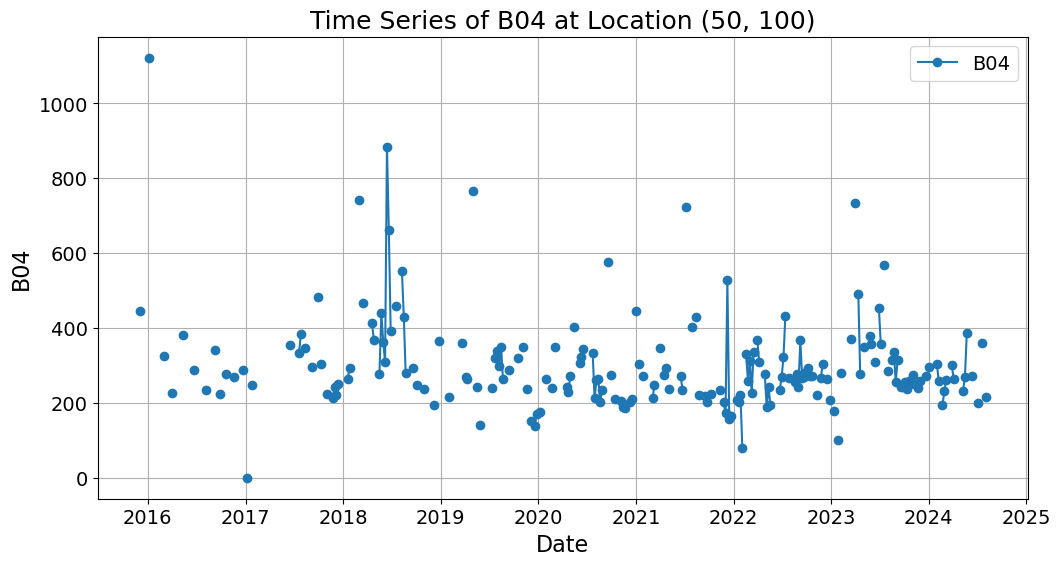

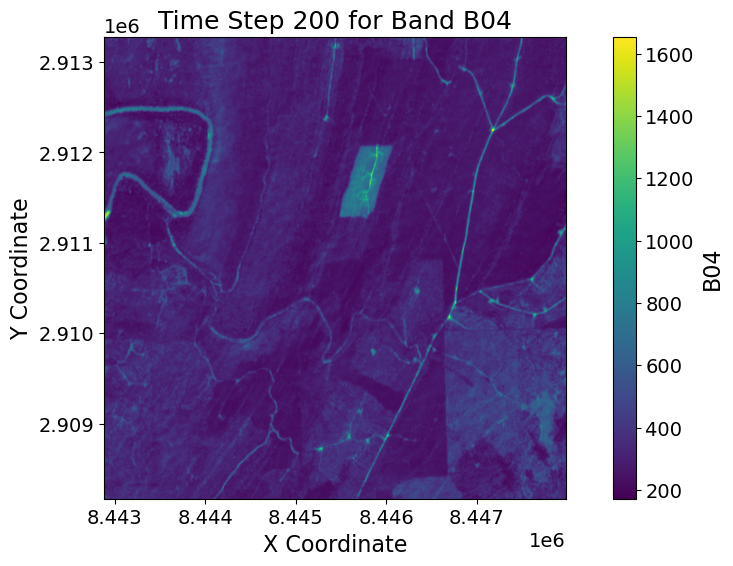

In [15]:
plot_band_timeseries(da, band='B04', x_idx=50, y_idx=100)
plot_timeslice(da, time_step=200, band='B04')

In [16]:
print(f" - Remove outliers")
# Remove outliers using a specified method
outliers = remove_outliers(da, method='median', user_factor=2, z_pval=0.07)

print(f" - Compute various vegetation indices")
# Compute various vegetation indices and add them to the dataset
outliers['ndvi'] = ndvi(outliers)
outliers['nbr'] = nbr(outliers)
outliers['ndwi'] = ndwi(outliers)
outliers['ndre'] = ndre(outliers)
outliers['tcw'] = tcw(outliers)
outliers['tcg'] = tcg(outliers)
outliers['tcb'] = tcb(outliers)
outliers['ndmi'] = ndmi(outliers)
outliers['nirv'] = nirv(outliers)
outliers['kndvi'] = kndvi(outliers, sigma=0.02)
outliers['drs'] = drs(outliers)
outliers['ndrs'] = ndrs(outliers)
outliers['kdrs'] = kdrs(outliers, sigma=0.02)
outliers['kndrs'] = kndrs(outliers)

print(f" - Sort temporal axis")
outliers = outliers.sortby('time')

print(f" - Interpolate linearly over time")
# Interpolate missing values linearly over time
# Rechunk the dataset so that the 'time' dimension is a single chunk
rechunked_data = outliers.chunk({'time': -1})

# Now perform interpolation
interpolated_data = rechunked_data.interpolate_na(dim='time', method='linear')

# Save the preprocessed data to a NetCDF file
# print(f" - Compress data for saving to complevel=9")
# comp = dict(zlib=True, complevel=9)
# encoding = {var: comp for var in smoothed_data.data_vars}
# print(f" -- {encoding}")


# Smooth the data using Savitzky-Golay filter
print(f" - Smooth data with Savitzky-Golay (window_length=15, polyorder=3)")
smoothed_data = smooth(ds=interpolated_data, method='savitsky', window_length=15, polyorder=3)

# Apply compression for saving, using Blosc for better performance
print(f" - Compress data for saving with Blosc (lz4, complevel=9)")
compressor = Blosc(cname="lz4", clevel=9, shuffle=Blosc.SHUFFLE)
encoding = {
    var: {
        "compressor": compressor,
        "write_empty_chunks": False
    } for var in smoothed_data.data_vars
}
print(f" -- {encoding}")

# Convert to Dask array with optimal chunk sizes
print(f" - Chunk data for optimal storage")
smoothed_data = smoothed_data.chunk({'time': 30, 'y': 512, 'x': 512})
print(smoothed_data.chunks)
#smoothed_data = smoothed_data.chunk({'time': -1, 'y': 512, 'x': 512})

# At this point, you can proceed to save the smoothed and chunked data.
smoothed_data

 - Remove outliers
Outlier removal method: median with a user factor of: 2
> Generated roll window size less than 3, setting to default (3).
> Warning: dataset contains nan values. You may want to interpolate next.
> Outlier removal successful.

 - Compute various vegetation indices
 - Sort temporal axis
 - Interpolate linearly over time
 - Smooth data with Savitzky-Golay (window_length=15, polyorder=3)
Smoothing method: savitsky with window length: 15, polyorder: 3  and mode: nearest.
> Warning: dataset contains nan values. You may want to interpolate next.
> Smoothing successful.

 - Compress data for saving with Blosc (lz4, complevel=9)
 -- {'B02': {'compressor': Blosc(cname='lz4', clevel=9, shuffle=SHUFFLE, blocksize=0), 'write_empty_chunks': False}, 'B07': {'compressor': Blosc(cname='lz4', clevel=9, shuffle=SHUFFLE, blocksize=0), 'write_empty_chunks': False}, 'kndrs': {'compressor': Blosc(cname='lz4', clevel=9, shuffle=SHUFFLE, blocksize=0), 'write_empty_chunks': False}, 'B09': {'

<xarray.Dataset> Size: 14GB
Dimensions:  (time: 462, x: 512, y: 512)
Coordinates:
  * time     (time) datetime64[ns] 4kB 2015-03-12 2015-05-21 ... 2024-08-01
  * x        (x) float32 2kB 8.443e+06 8.443e+06 ... 8.448e+06 8.448e+06
  * y        (y) float32 2kB 2.913e+06 2.913e+06 ... 2.908e+06 2.908e+06
Data variables: (12/28)
    B02      (time, y, x) float32 484MB dask.array<chunksize=(30, 512, 512), meta=np.ndarray>
    B07      (time, y, x) float32 484MB dask.array<chunksize=(30, 512, 512), meta=np.ndarray>
    kndrs    (time, y, x) float32 484MB dask.array<chunksize=(30, 512, 512), meta=np.ndarray>
    B09      (time, y, x) float32 484MB dask.array<chunksize=(30, 512, 512), meta=np.ndarray>
    ndmi     (time, y, x) float32 484MB dask.array<chunksize=(30, 512, 512), meta=np.ndarray>
    tcw      (time, y, x) float32 484MB dask.array<chunksize=(30, 512, 512), meta=np.ndarray>
    ...       ...
    ndvi     (time, y, x) float32 484MB dask.array<chunksize=(30, 512, 512), meta=np.ndarray>
    B11      (time, y, x) float32 484MB dask.array<chunksize=(30, 512, 512), meta=np.ndarray>
    B08      (time, y, x) float32 484MB dask.array<chunksize=(30, 512, 512), meta=np.ndarray>
    B06      (time, y, x) float32 484MB dask.array<chunksize=(30, 512, 512), meta=np.ndarray>
    tcg      (time, y, x) float32 484MB dask.array<chunksize=(30, 512, 512), meta=np.ndarray>
    kndvi    (time, y, x) float32 484MB dask.array<chunksize=(30, 512, 512), meta=np.ndarray>

In [34]:
# Step 3: Save the smoothed data to a NetCDF file
#smoothed_data.to_netcdf(nc_path)

/net/home/fmueller/.conda/envs/emp/lib/python3.12/site-packages/dask/utils.py:78: RuntimeWarning: All-NaN slice encountered
  return func(*args, **kwargs)
/net/home/fmueller/.conda/envs/emp/lib/python3.12/site-packages/dask/utils.py:78: RuntimeWarning: All-NaN slice encountered
  return func(*args, **kwargs)
/net/home/fmueller/.conda/envs/emp/lib/python3.12/site-packages/dask/utils.py:78: RuntimeWarning: All-NaN slice encountered
  return func(*args, **kwargs)
/net/home/fmueller/.conda/envs/emp/lib/python3.12/site-packages/dask/utils.py:78: RuntimeWarning: All-NaN slice encountered
  return func(*args, **kwargs)


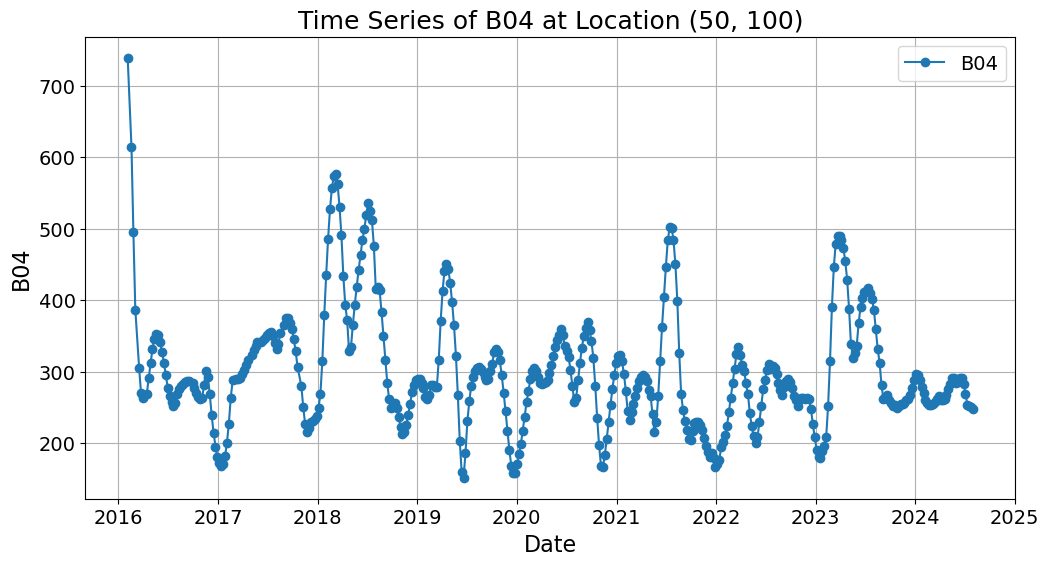

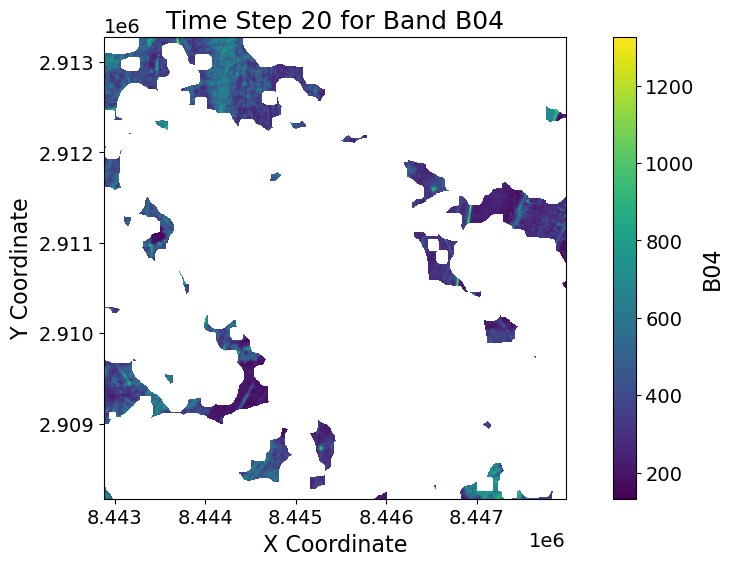

In [17]:
plot_band_timeseries(smoothed_data, band='B04', x_idx=50, y_idx=100)
plot_timeslice(smoothed_data, time_step=20, band='B04')

In [27]:
#save_as_zarr(smoothed_data, encoding, path)
 # Check if the folder exists, then delete it along with all its subfolders
if os.path.exists(path):
    print(f"Deleting folder and subfolders at: {path}")
    shutil.rmtree(path)
else:
    print(f"Folder does not exist: {path}")

print(f"Saving data at: {path}")

store = zarr.storage.DirectoryStore(path, dimension_separator=".")
da.to_zarr(store=store, mode="w-",compute=True)

print(f"Succesfully saved at: {path}")

Deleting folder and subfolders at: /net/projects/forexd/WP1/Data/S2_Cubes_IDS_R8//0_10_512_20152024_equi7_NA.zarr
Saving data at: /net/projects/forexd/WP1/Data/S2_Cubes_IDS_R8//0_10_512_20152024_equi7_NA.zarr


Succesfully saved at: /net/projects/forexd/WP1/Data/S2_Cubes_IDS_R8//0_10_512_20152024_equi7_NA.zarr


In [ ]:
path = f"{os.getenv('SENTINEL2_MINICUBES')}/{idx}_10_512_20152024_equi7_NA.zarr"
ds = xr.open_zarr(path)
plot_band_timeseries(ds, band='B04', x_idx=50, y_idx=100)
plot_timeslice(ds, time_step=20, band='B04')